# Cost Function for Logistic Regression

In [1]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from lab_utils_common import  plot_data, sigmoid, dlc
plt.style.use('./deeplearning.mplstyle')

## Data Set

In [3]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])  #(m,n)
y_train = np.array([0, 0, 0, 1, 1, 1])                                           #(m,)

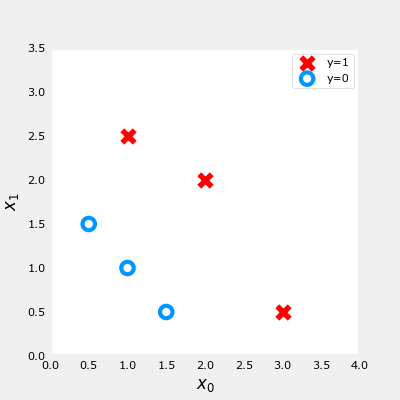

In [4]:
fig,ax = plt.subplots(1,1,figsize=(4,4))
plot_data(X_train, y_train, ax)

# Set both axes to be from 0-4
ax.axis([0, 4, 0, 3.5])
ax.set_ylabel('$x_1$', fontsize=12)
ax.set_xlabel('$x_0$', fontsize=12)
plt.show()

Recall that for logistic regression, the cost function is of the form:

$$ J(\mathbf{w}, b) = \frac{1}{m} \sum_{i=0}^{m-1} \left[ \text{loss}(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] $$

where:
- $\text{loss}(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost for a single data point:

$$ \text{loss}(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = -y^{(i)} \log\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)})\right) - \left(1 - y^{(i)}\right) \log\left(1 - f_{\mathbf{w},b}(\mathbf{x}^{(i)})\right) $$

- $m$ is the number of training examples
- $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is defined as:

$$ f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(z^{(i)}) $$
$$ z^{(i)} = \mathbf{w} \cdot \mathbf{x}^{(i)} + b $$
$$ g(z^{(i)}) = \frac{1}{1 + e^{-z^{(i)}}} $$

### Code Description
The algorithm for ```compute_cost_logistic``` uses:
- variables X, y: shape $(m, n)$ and $(m,)$
- $n$ is the number of features
- $m$ is the number of training examples

In [7]:
def compute_cost_logistic(X, y, w, b):
    """
    Computes cost

    Args:
        X (ndarray (m,n)): Data, m examples with n features
        y (ndarray (m,)): target values
        w (ndarray (n,)): model parameters
        b (scalar): model parameter

    Returns:
        cost (scalar): cost
    """

    m = X.shape[0]
    cost = 0

    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb_i = sigmoid(z_i)
        cost +=  -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)

    cost /= m
    return cost

In [8]:
w_tmp = np.array([1,1])
b_tmp = -3
print(compute_cost_logistic(X_train, y_train, w_tmp, b_tmp))

0.36686678640551745


## Example
see what the cost function output is for a different value of $w$

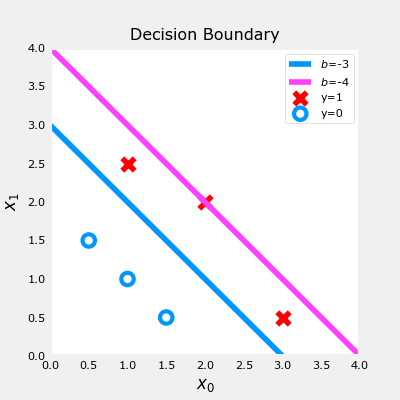

In [9]:
import matplotlib.pyplot as plt

# choose values between 0 and 6
x0 = np.arange(0, 6)

# plot two dicision boundaries
x1 = 3 - x0
x1_other = 4 - x0

# Plot 
fig, ax = plt.subplots(1, 1, figsize=(4,4))
ax.plot(x0,x1, c=dlc["dlblue"], label="$b$=-3")
ax.plot(x0,x1_other, c=dlc["dlmagenta"], label="$b$=-4")
ax.axis([0, 4, 0, 4])

# Plot the original data
plot_data(X_train,y_train,ax)
ax.axis([0, 4, 0, 4])
ax.set_ylabel('$x_1$', fontsize=12)
ax.set_xlabel('$x_0$', fontsize=12)
plt.legend(loc="upper right")
plt.title("Decision Boundary")
plt.show()

In [10]:
w_array1 = np.array([1,1])
b_1 = -3
w_array2 = np.array([1,1])
b_2 = -4

print("Cost for b = -3 : ", compute_cost_logistic(X_train, y_train, w_array1, b_1))
print("Cost for b = -4 : ", compute_cost_logistic(X_train, y_train, w_array2, b_2))

Cost for b = -3 :  0.36686678640551745
Cost for b = -4 :  0.5036808636748461
